# RED NEURONAL CONVOLUCIONAL PARA CLASIFICACIÓN DE IMAGENES DE PERROS Y GATOS
## DATASET [KAGGLE](https://www.kaggle.com/competitions/dogs-vs-cats/overview)

# 1 - GARGAMOS IMAGENES PARA EL DATASET

## IMPORTAMOS LIBRERIAS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
BASE_DIR = '/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets'

# CARGAMOS PATH DE IMAGENES

In [5]:
import os
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VALIDATION_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
print(TRAIN_DIR)
print(VALIDATION_DIR)
print(TEST_DIR)

/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test


## CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE PERROS Y GATOS

In [6]:
train_gatos_dir = os.path.join(TRAIN_DIR,'gatos')
train_perros_dir = os.path.join(TRAIN_DIR, 'perros')

validation_gatos_dir = os.path.join(VALIDATION_DIR, 'gatos')
validation_perros_dir = os.path.join(VALIDATION_DIR, 'perros')

test_gatos_dir = os.path.join(TEST_DIR, 'gatos')
test_perros_dir = os.path.join(TEST_DIR, 'perros')

print(train_gatos_dir)
print(train_perros_dir)
print(validation_gatos_dir)
print(validation_perros_dir)
print(test_gatos_dir)
print(test_perros_dir)

/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/gatos
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/perros
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/gatos
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/perros
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/gatos
/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/perros


# PROBAMOS LA CARGA DE IMAGENES ALEATORIAS DE PERROS Y GATOS

In [7]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def mostrar_imagenes_aleatorias(directorio, num_imagenes=5):
    # Obtener lista de archivos de imagen en el directorio
    imagenes = os.listdir(directorio)

    # Filtrar archivos para obtener solo las imágenes (por ejemplo, con extensiones jpg o png)
    imagenes = [img for img in imagenes if img.endswith(('.jpg', '.jpeg', '.png'))]

    # Seleccionar imágenes aleatorias
    imagenes_aleatorias = random.sample(imagenes, min(num_imagenes, len(imagenes)))

    # Mostrar las imágenes seleccionadas
    for img_name in imagenes_aleatorias:
        img_path = os.path.join(directorio, img_name)
        img = mpimg.imread(img_path)

        plt.figure()
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')  # Ocultar los ejes
        plt.show()

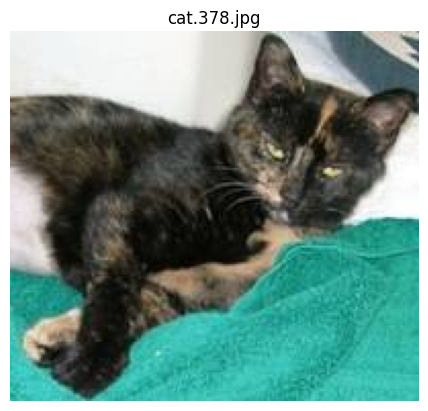

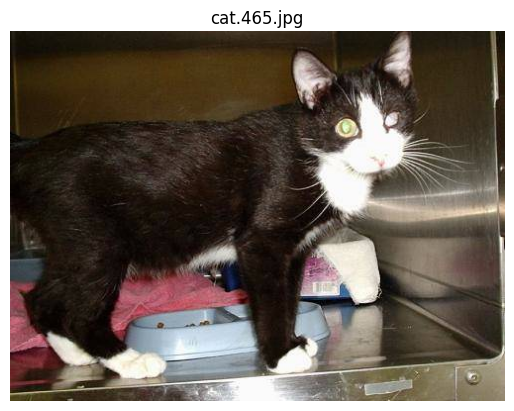

In [9]:
mostrar_imagenes_aleatorias(train_gatos_dir,2)

## Mostramos que cantidades de archivos hay en cada carpeta

In [10]:
dataset_dir = [train_gatos_dir,train_perros_dir,validation_gatos_dir,validation_perros_dir,test_gatos_dir,test_perros_dir]
for img_dir in dataset_dir:
  print(f" en directorio :{img_dir} hay {len(os.listdir(img_dir))} imagenes")

 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/gatos hay 1000 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/train/perros hay 1000 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/gatos hay 500 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/validation/perros hay 500 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/gatos hay 1 imagenes
 en directorio :/content/drive/MyDrive/CODIGOG7/MODULO6/3-REDES-NEURONALES-CONVOLUCIONALES/datasets/test/perros hay 1 imagenes


# 2 - CONVERTIR IMAGENES A ARRAY DE DATOS

In [11]:
from keras.preprocessing import image
import matplotlib.pyplot as plt

In [12]:
fnames = [os.path.join(train_perros_dir,fname) for fname in os.listdir(train_perros_dir)]
img_path = fnames[1]
img = image.load_img(img_path,target_size=(64,64))
x = image.img_to_array(img)

In [13]:
x

array([[[228., 182., 146.],
        [180., 131.,  98.],
        [191., 149., 111.],
        ...,
        [ 94.,  49.,   8.],
        [ 95.,  51.,  16.],
        [116.,  75.,  55.]],

       [[193., 149., 120.],
        [210., 170., 134.],
        [182., 145.,  93.],
        ...,
        [134.,  90.,  45.],
        [111.,  66.,  33.],
        [ 92.,  55.,  39.]],

       [[186., 135., 104.],
        [187., 145.,  97.],
        [237., 200., 147.],
        ...,
        [215., 170., 128.],
        [232., 189., 154.],
        [ 98.,  60.,  41.]],

       ...,

       [[171., 127.,  88.],
        [242., 212., 160.],
        [213., 180., 126.],
        ...,
        [187., 137.,  76.],
        [116.,  72.,  25.],
        [ 98.,  53.,  34.]],

       [[231., 182., 139.],
        [175., 131.,  96.],
        [157., 115.,  75.],
        ...,
        [119.,  67.,  20.],
        [106.,  58.,  35.],
        [158., 111.,  83.]],

       [[201., 151., 128.],
        [212., 155., 126.],
        [226., 1

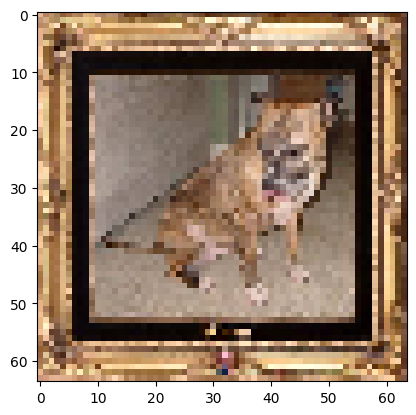

In [14]:
plt.figure()
imgplot = plt.imshow(image.array_to_img(x))
plt.show()

# CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [15]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [17]:
training_set = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    VALIDATION_DIR,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    TEST_DIR,
    target_size=(64,64),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


# 3 -CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL

In [19]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [20]:
modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
modelo.add(MaxPooling2D(2,2))
modelo.add(Conv2D(32,(3,3),activation='relu'))
modelo.add(MaxPooling2D(2,2))
modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILAR LA RED NEURONAL

In [21]:
modelo.compile(loss="binary_crossentropy",
               optimizer='adam',
               metrics=['accuracy'])

# ENTRENAMOS EL MODELO

In [22]:
history = modelo.fit(training_set,epochs=3,batch_size=100,validation_data=validation_set)

Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 1826s 29s/step - accuracy: 0.5000 - loss: 0.7006 - val_accuracy: 0.5120 - val_loss: 0.6894
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.5805 - loss: 0.6751 - val_accuracy: 0.6370 - val_loss: 0.6455
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step - accuracy: 0.6475 - loss: 0.6399 - val_accuracy: 0.6880 - val_loss: 0.6257


# EVALUAMOS EL MODELO

In [23]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step - accuracy: 1.0000 - loss: 0.6128
[0.612766683101654, 1.0]


# REALIZAMOS PREDICCIÓN DEL MODELO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
predicción :  [[7.69577e-07]]
Es un gato


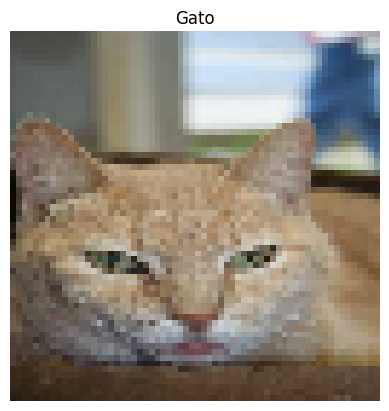

In [35]:
from keras.preprocessing import image
#gato = image.load_img(test_gatos_dir + "/cat.1000.jpg",target_size=(64,64))
perro = image.load_img(test_perros_dir + "/dog.1000.jpg",target_size=(64,64))
gato = image.load_img('/content/cat.41.jpg',target_size=(64,64))
imagen_prueba = gato

test_image = image.img_to_array(imagen_prueba)
test_image = np.expand_dims(test_image,axis=0)
training_set.class_indices


result = modelo.predict(test_image)
result_round = np.round(result)
print("predicción : ",result)
if result_round == 0:
  print("Es un gato")
  plt.imshow(imagen_prueba)
  plt.title('Gato')
  plt.axis('off')
  plt.show()
else:
  print("Es un perro")
  plt.imshow(imagen_prueba)
  plt.title('Perro')
  plt.axis('off')
  plt.show()

# GRAFICAMOS ACCURACY Y LOSS

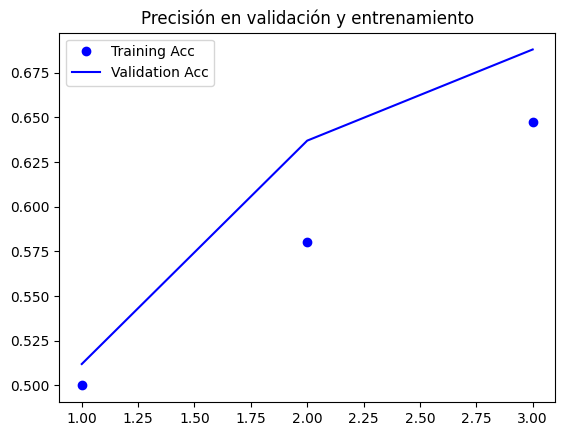

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

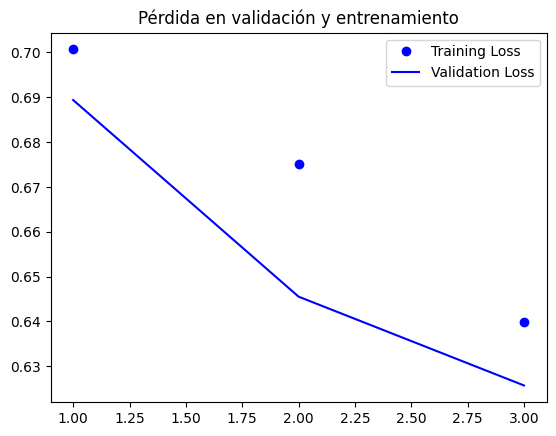

In [29]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()